In [8]:
import pandas as pd
df = pd.read_csv(
    "DDOS_O.csv"
)

df["Label"] = df["Label"].astype(str).str.strip()

df["Label"] = df["Label"].replace({
    "BENIGN": 0,
    "DDoS": 1
})

/tmp/ipykernel_505/3070817889.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Label"] = df["Label"].replace({


In [9]:
print(df["Label"].unique())

print(df["Label"].value_counts())

[0 1]
Label
0    19810
1     9001
Name: count, dtype: int64


In [10]:
print(df.shape)


print(df["Label"].value_counts(dropna=False))

(28811, 79)
Label
0    19810
1     9001
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
!pip install xgboost -q

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
xgb_pred = xgb.predict(
    X_test
)

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [16]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3963
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      5763
   macro avg       1.00      1.00      1.00      5763
weighted avg       1.00      1.00      1.00      5763

[[3963    0]
 [   0 1800]]


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
13,Bwd Packet Length Std,0.414871
52,Average Packet Size,0.189665
6,Fwd Packet Length Max,0.167171
68,act_data_pkt_fwd,0.131592
4,Total Length of Fwd Packets,0.076209
8,Fwd Packet Length Mean,0.006775
3,Total Backward Packets,0.003834
66,Init_Win_bytes_forward,0.001364
0,Destination Port,0.001065
14,Flow Bytes/s,0.000627


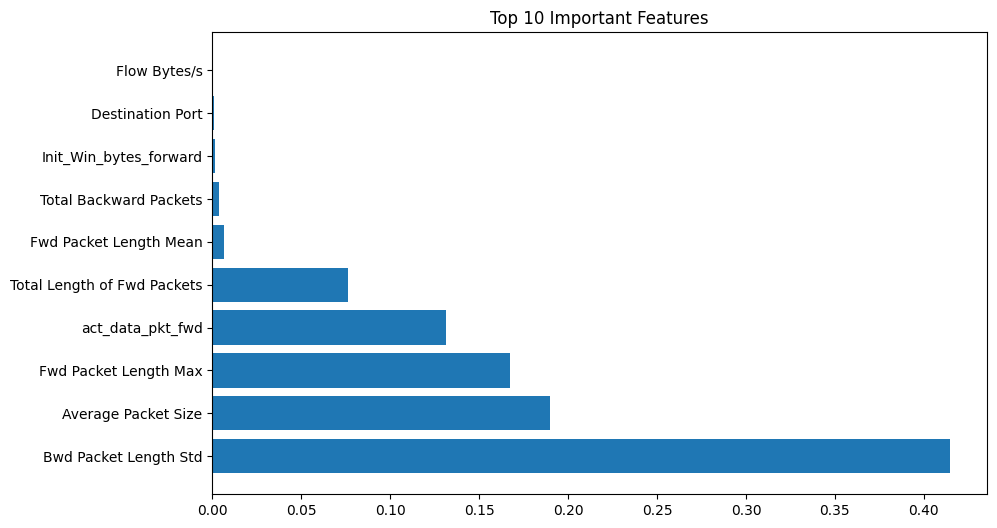

In [18]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [20]:
import joblib

joblib.dump(
    xgb,
    "xgboost_model.pkl"
)

['xgboost_model.pkl']